# Estudo Dirigido 6 - Avaliação e Ensemble Learning

**Sobre os dados:** 

O banco de dados contém registros de 1.885 entrevistados. Para cada entrevistado, 12 atributos são conhecidos. Além disso, os participantes foram questionados sobre o uso de 18 drogas legais e ilegais e uma droga fictícia (Semeron) que foi introduzida para identificar os que faziam uso excessivo. O banco de dados contém 18 problemas de classificação (previsão de consumo de cada droga). Cada uma das variáveis de drogas contém sete classes (CLX): 0 "Nunca usado", 1 "Usado há mais de uma década", 2 "Usado na última década", 3 "Usado no último ano", 4 "Usado no último mês", 5 "Usado na última semana" e 6 "Usado no último dia".

**Atividade:**

Considerando o dataset anexo ("drug_consuption"), escolha uma das variáveis que indicam consumo de drogas (Alcohol, Amphet, Amyl, Benzos, Caff, Cannabis, Choc, Coke, Crack, Ecstasy, Heroin, Ketamine, Legalh, LSD, Meth, Mushrooms, Nicotine, Semer, VSA) e implemente um classificador multiclasse. As variáveis base estão codificadas numericamente. Implemente um comparativo de eficácia de dois algoritmos classificadores básicos e dois métodos baseados em ensemble learning. Utilize medidas e protocolos de avaliação adequados.

## 1. Carregamento dos dados

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [90]:
df = pd.read_csv("./drug_consumption.csv")
df

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,1,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,2,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,3,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,4,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,5,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880,1884,-0.95197,0.48246,-0.61113,-0.57009,-0.31685,-1.19430,1.74091,1.88511,0.76096,...,CL0,CL0,CL0,CL3,CL3,CL0,CL0,CL0,CL0,CL5
1881,1885,-0.95197,-0.48246,-0.61113,-0.57009,-0.31685,-0.24649,1.74091,0.58331,0.76096,...,CL2,CL0,CL0,CL3,CL5,CL4,CL4,CL5,CL0,CL0
1882,1886,-0.07854,0.48246,0.45468,-0.57009,-0.31685,1.13281,-1.37639,-1.27553,-1.77200,...,CL4,CL0,CL2,CL0,CL2,CL0,CL2,CL6,CL0,CL0
1883,1887,-0.95197,0.48246,-0.61113,-0.57009,-0.31685,0.91093,-1.92173,0.29338,-1.62090,...,CL3,CL0,CL0,CL3,CL3,CL0,CL3,CL4,CL0,CL0


In [91]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1885 entries, 0 to 1884
Data columns (total 32 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   ID         1885 non-null   int64  
 1   Age        1885 non-null   float64
 2   Gender     1885 non-null   float64
 3   Education  1885 non-null   float64
 4   Country    1885 non-null   float64
 5   Ethnicity  1885 non-null   float64
 6   Nscore     1885 non-null   float64
 7   Escore     1885 non-null   float64
 8   Oscore     1885 non-null   float64
 9   Ascore     1885 non-null   float64
 10  Cscore     1885 non-null   float64
 11  Impulsive  1885 non-null   float64
 12  SS         1885 non-null   float64
 13  Alcohol    1885 non-null   str    
 14  Amphet     1885 non-null   str    
 15  Amyl       1885 non-null   str    
 16  Benzos     1885 non-null   str    
 17  Caff       1885 non-null   str    
 18  Cannabis   1885 non-null   str    
 19  Choc       1885 non-null   str    
 20  Coke       1885 non

In [92]:
df.describe()

,ID,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,Cscore,Impulsive,SS
count,1885.000000,1885.00000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000
mean,945.294960,0.03461,-0.000256,-0.003806,0.355542,-0.309577,0.000047,-0.000163,-0.000534,-0.000245,-0.000386,0.007216,-0.003292
std,545.167641,0.87836,0.482588,0.950078,0.700335,0.166226,0.998106,0.997448,0.996229,0.997440,0.997523,0.954435,0.963701
min,1.000000,-0.95197,-0.482460,-2.435910,-0.570090,-1.107020,-3.464360,-3.273930,-3.273930,-3.464360,-3.464360,-2.555240,-2.078480
25%,474.000000,-0.95197,-0.482460,-0.611130,-0.570090,-0.316850,-0.678250,-0.695090,-0.717270,-0.606330,-0.652530,-0.711260,-0.525930
50%,946.000000,-0.07854,-0.482460,-0.059210,0.960820,-0.316850,0.042570,0.003320,-0.019280,-0.017290,-0.006650,-0.217120,0.079870
75%,1417.000000,0.49788,0.482460,0.454680,0.960820,-0.316850,0.629670,0.637790,0.723300,0.760960,0.584890,0.529750,0.765400
max,1888.000000,2.59171,0.482460,1.984370,0.960820,1.907250,3.273930,3.273930,2.901610,3.464360,3.464360,2.901610,1.921730


## 2. EDA

In [93]:
colunas_demograficas = ['Age', 'Gender', 'Education', 'Country', 'Ethnicity']

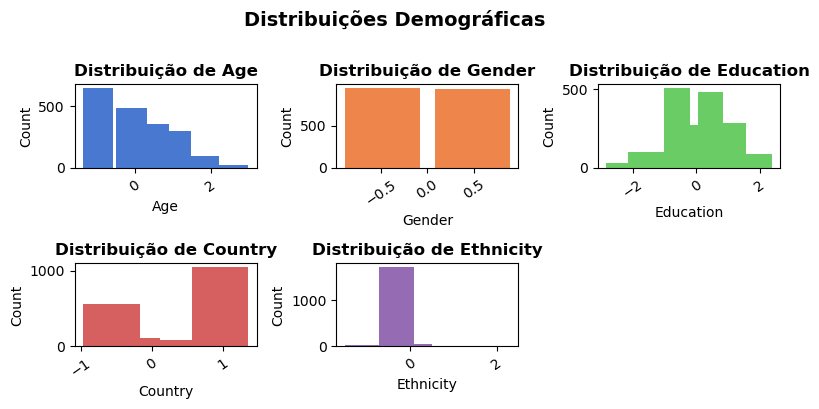

In [94]:
fig, axes = plt.subplots(2, 3, figsize=(8, 4))
axes = axes.flatten()

for i, col in enumerate(colunas_demograficas):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color=sns.color_palette('muted')[i])
    axes[i].set_title(f'Distribuição de {col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=35)

# Hide the unused 6th subplot
axes[5].set_visible(False)
plt.suptitle('Distribuições Demográficas', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

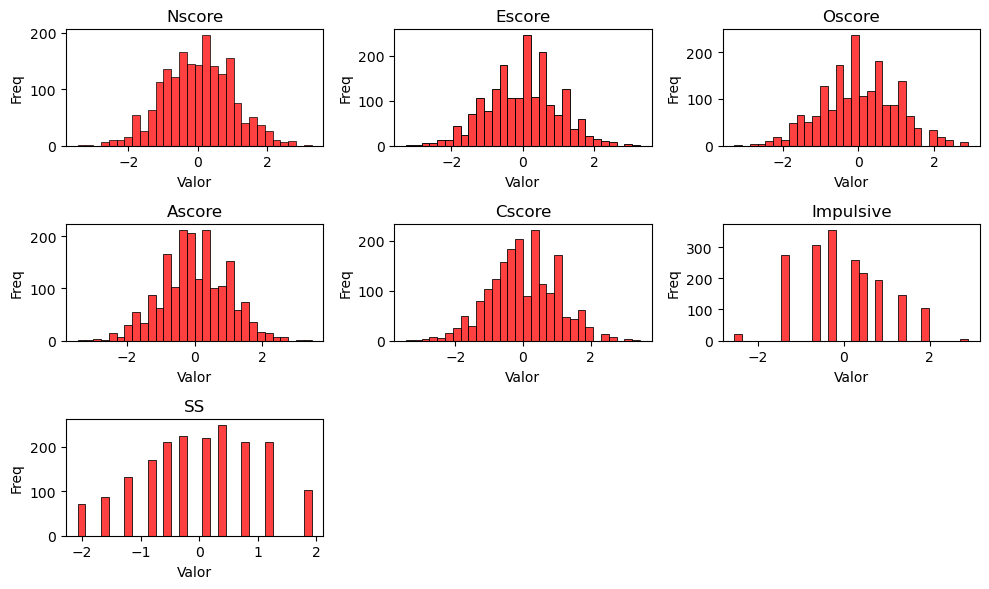

In [95]:

features_numericas = df[['Nscore','Escore','Oscore','Ascore','Cscore','Impulsive','SS']]

plt.figure(figsize=(10,6))
for i, col in enumerate(features_numericas.columns, 1):
    plt.subplot(3, 3, i)
    sns.histplot(features_numericas[col], bins=30, color= 'red', edgecolor='black')
    plt.title(col)
    plt.xlabel('Valor')
    plt.ylabel('Freq')
    plt.tight_layout()


In [96]:
df["Cannabis"].value_counts().sort_index()

Cannabis
CL0    413
CL1    207
CL2    266
CL3    211
CL4    140
CL5    185
CL6    463
Name: count, dtype: int64

## 3. Pré-processamento dos dados

In [97]:
from sklearn.preprocessing import LabelEncoder
df = df.drop(columns=["ID"])

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df.head()

,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,Cscore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
0,0.49788,1,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
1,-0.07854,0,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,-0.14277,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
2,0.49788,0,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
3,-0.95197,1,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,0.58489,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
4,0.49788,1,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,1.30612,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0


Outliers por IQR
Nscore      :  19 outliers (1.0%)  |  limites: [-2.64, 2.59]
Escore      :  14 outliers (0.7%)  |  limites: [-2.69, 2.64]
Oscore      :   9 outliers (0.5%)  |  limites: [-2.88, 2.88]
Ascore      :   9 outliers (0.5%)  |  limites: [-2.66, 2.81]
Cscore      :  24 outliers (1.3%)  |  limites: [-2.51, 2.44]
Impulsive   :   7 outliers (0.4%)  |  limites: [-2.57, 2.39]
SS          :   0 outliers (0.0%)  |  limites: [-2.46, 2.70]


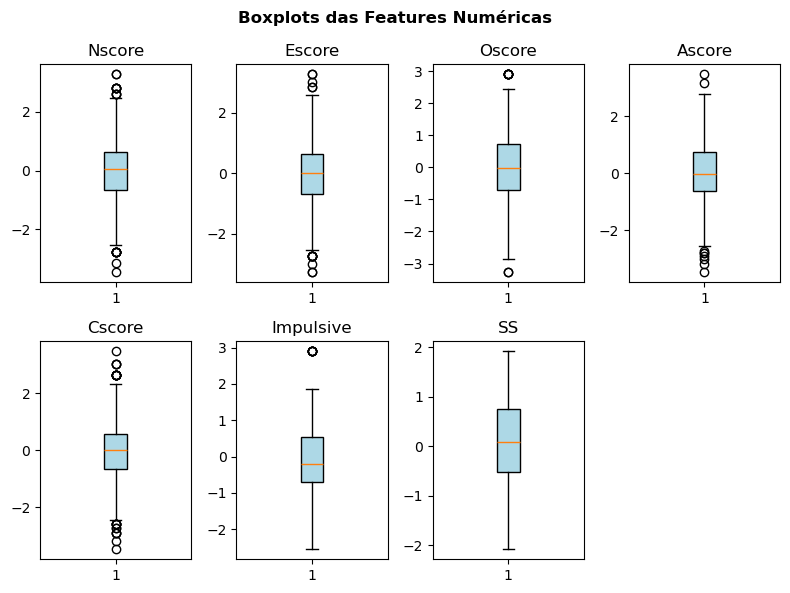

In [98]:
print('Outliers por IQR')
for col in features_numericas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'{col:12s}: {n_out:3d} outliers ({n_out/len(df)*100:.1f}%)  |  limites: [{lower:.2f}, {upper:.2f}]')

fig, axes = plt.subplots(2, 4, figsize=(8, 6))
axes = axes.flatten()
for i, col in enumerate(features_numericas):
    axes[i].boxplot(df[col].dropna(), patch_artist=True, boxprops=dict(facecolor='lightblue'))
    axes[i].set_title(col)
axes[-1].set_visible(False)
plt.suptitle('Boxplots das Features Numéricas', fontweight='bold')
plt.tight_layout()
plt.show()

In [99]:
mapping = {'CL0': 0, 'CL1': 1, 'CL2': 2, 'CL3': 3, 'CL4': 4, 'CL5': 5, 'CL6': 6}
drug_cols = ['Alcohol','Amphet','Amyl','Benzos','Caff','Choc','Coke','Crack',
             'Ecstasy','Heroin','Ketamine','Legalh','LSD','Meth','Mushrooms',
             'Nicotine','Semer','VSA', 'Cannabis']
for col in drug_cols:
    df[col] = df[col].replace(mapping)

features_cols = ['Age', 'Gender', 'Education', 'Country', 'Ethnicity',
                    'Nscore', 'Escore', 'Oscore', 'Ascore', 'Cscore', 'Impulsive', 'SS',
                    'Alcohol', 'Nicotine', 'Ecstasy', 'LSD']
X = df[features_cols]

Cannabis
2    788
0    620
1    477
Name: count, dtype: int64


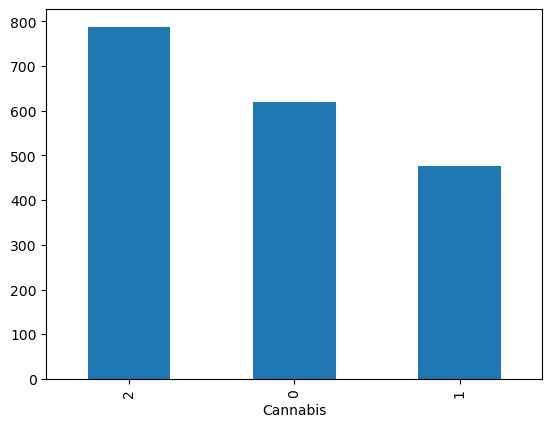

In [100]:
def group_classes(val):
     # CL0 e CL1
    if val in [0, 1]:   
        return 0
    # CL2 e CL3
    elif val in [2, 3]:  
        return 1
    # CL4, CL5, CL6
    else:                
        return 2

y = df['Cannabis'].apply(group_classes)

# def agrupar_binario(val):
#     return 1 if val >= 4 else 0

# y = df['Cannabis'].apply(agrupar_binario)
classes_count = y.value_counts()
print(classes_count)

classes_count.plot(kind='bar')
plt.show()


## 4. Treinamento 

In [101]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [102]:
from sklearn.model_selection import StratifiedKFold

# Esquema padrão de validação cruzada padrão para os GridSearch
cv_padrao = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [103]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.pipeline import Pipeline

#f1-macro é o f1-score dando o mesmo peso para cada classe

param_grid_rf = {
    'n_estimators': [300, 500, 800],
    'max_depth': [10, 15, 20, 300],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
}

pipe_rf = Pipeline([
    ('rf', RandomForestClassifier(class_weight='balanced', random_state=42))
])
param_grid_rf = {
    'rf__n_estimators': [100, 200, 300], 
    'rf__max_depth': [10, 20, 30],
    'rf__min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=cv_padrao, scoring='f1_macro', n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Melhores parâmetros:")
print(grid_rf.best_params_)

print("\nMelhor F1 Macro:")
print(grid_rf.best_score_)

Melhores parâmetros:
{'rf__max_depth': 30, 'rf__min_samples_split': 5, 'rf__n_estimators': 300}

Melhor F1 Macro:
0.6936916598900063


In [104]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

param_grid_knn = {
    'knn__n_neighbors': [3, 5, 7, 9, 11],
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    pipe_knn, 
    param_grid_knn, 
    cv=cv_padrao, 
    scoring='f1_macro', 
    n_jobs=-1
)
grid_knn.fit(X_train, y_train)

print("Melhores parâmetros:")
print(grid_knn.best_params_)

print("\nMelhor F1 Macro:")
print(grid_knn.best_score_)

Melhores parâmetros:
{'knn__metric': 'manhattan', 'knn__n_neighbors': 11, 'knn__weights': 'distance'}

Melhor F1 Macro:
0.6595241609793288


In [105]:
from sklearn.tree import DecisionTreeClassifier


param_grid_dt = {
    'max_depth': [5, 10, 15, 20, 25],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

#to-do:depois adicionar possiveis ajustos no pipe
pipe_dt = Pipeline([
    ('dt', DecisionTreeClassifier(class_weight='balanced', random_state=42)) 
])
param_grid_dt = {
    'dt__max_depth': [5, 10, 15, 20],
    'dt__min_samples_split': [2, 5]
}
grid_dt = GridSearchCV(
    pipe_dt, 
    param_grid_dt, 
    cv=cv_padrao, 
    scoring='f1_macro', 
    n_jobs=-1
)
grid_dt.fit(X_train, y_train)

print(grid_dt.best_params_)
print(grid_dt.best_score_)

{'dt__max_depth': 5, 'dt__min_samples_split': 2}
0.6543259717319271


In [106]:
param_grid_ab = {
    'n_estimators': [50, 100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.5, 1.0]
}

pipe_ab = Pipeline([
    ('ab', AdaBoostClassifier(random_state=42))
])
param_grid_ab = {
    'ab__n_estimators': [50, 100, 200],
    'ab__learning_rate': [0.1, 0.5, 1.0]
}
grid_ab = GridSearchCV(
    pipe_ab, 
    param_grid_ab, 
    cv=cv_padrao, 
    scoring='f1_macro', 
    n_jobs=-1
)
grid_ab.fit(X_train, y_train)

print(grid_ab.best_params_)
print(grid_ab.best_score_)

{'ab__learning_rate': 1.0, 'ab__n_estimators': 100}
0.6847796716736202



KNN
Accuracy de Teste: 0.6631
F1 Macro Médio (CV): 0.6595
Desvio padrão do CV: 0.0334
              precision    recall  f1-score   support

           0       0.68      0.81      0.74       124
           1       0.39      0.25      0.31        95
           2       0.74      0.79      0.77       158

    accuracy                           0.66       377
   macro avg       0.61      0.62      0.61       377
weighted avg       0.64      0.66      0.64       377


Decision Tree
Accuracy de Teste: 0.6605
F1 Macro Médio (CV): 0.6543
Desvio padrão do CV: 0.0175
              precision    recall  f1-score   support

           0       0.73      0.79      0.76       124
           1       0.39      0.44      0.42        95
           2       0.80      0.69      0.74       158

    accuracy                           0.66       377
   macro avg       0.64      0.64      0.64       377
weighted avg       0.68      0.66      0.67       377


Random Forest
Accuracy de Teste: 0.7056
F1 Macro Médi

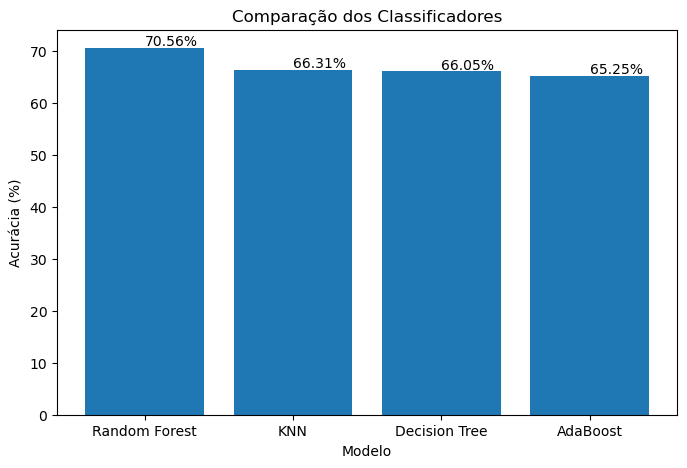

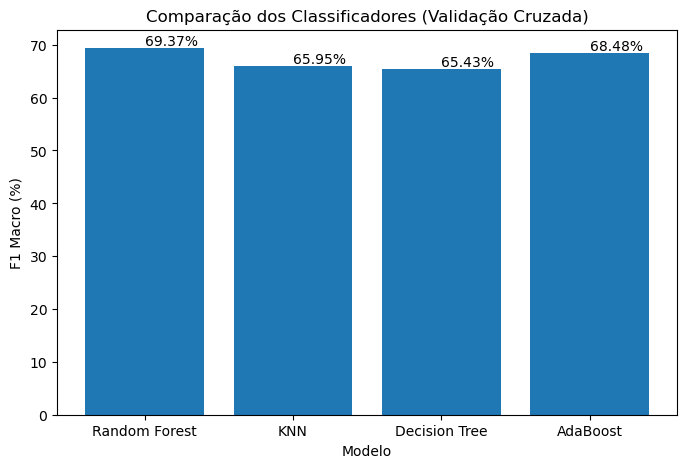

In [107]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

models = {
    "KNN": grid_knn.best_estimator_,
    "Decision Tree": grid_dt.best_estimator_,
    "Random Forest": grid_rf.best_estimator_,
    "AdaBoost": grid_ab.best_estimator_
}

resultados = []

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    
    cv_scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=cv_padrao,
        scoring='f1_macro',
        n_jobs=-1
    )

    resultados.append({
        "Modelo": name,
        "Acurácia": acc * 100,
        "F1 Macro (CV)": cv_scores.mean() * 100
    })

    print(f"\n{'='*50}\n{name}\n{'='*50}")
    print("Accuracy de Teste:", round(acc, 4))
    print("F1 Macro Médio (CV):", round(cv_scores.mean(), 4))
    print("Desvio padrão do CV:", round(cv_scores.std(), 4))
    print(classification_report(y_test, y_pred))

df_resultados = pd.DataFrame(resultados)

df_resultados = df_resultados.sort_values(
    by="Acurácia",
    ascending=False
)

print(df_resultados)

plt.figure(figsize=(8,5))

plt.bar(
    df_resultados["Modelo"],
    df_resultados["Acurácia"]
)

plt.title("Comparação dos Classificadores")
plt.ylabel("Acurácia (%)")
plt.xlabel("Modelo")

for i, v in enumerate(df_resultados["Acurácia"]):
    plt.text(i, v + 0.5, f"{v:.2f}%")

plt.show()

plt.figure(figsize=(8,5))

plt.bar(
    df_resultados["Modelo"],
    df_resultados["F1 Macro (CV)"]
)

plt.title("Comparação dos Classificadores (Validação Cruzada)")
plt.ylabel("F1 Macro (%)")
plt.xlabel("Modelo")

for i, v in enumerate(df_resultados["F1 Macro (CV)"]):
    plt.text(i, v + 0.5, f"{v:.2f}%")

plt.show()

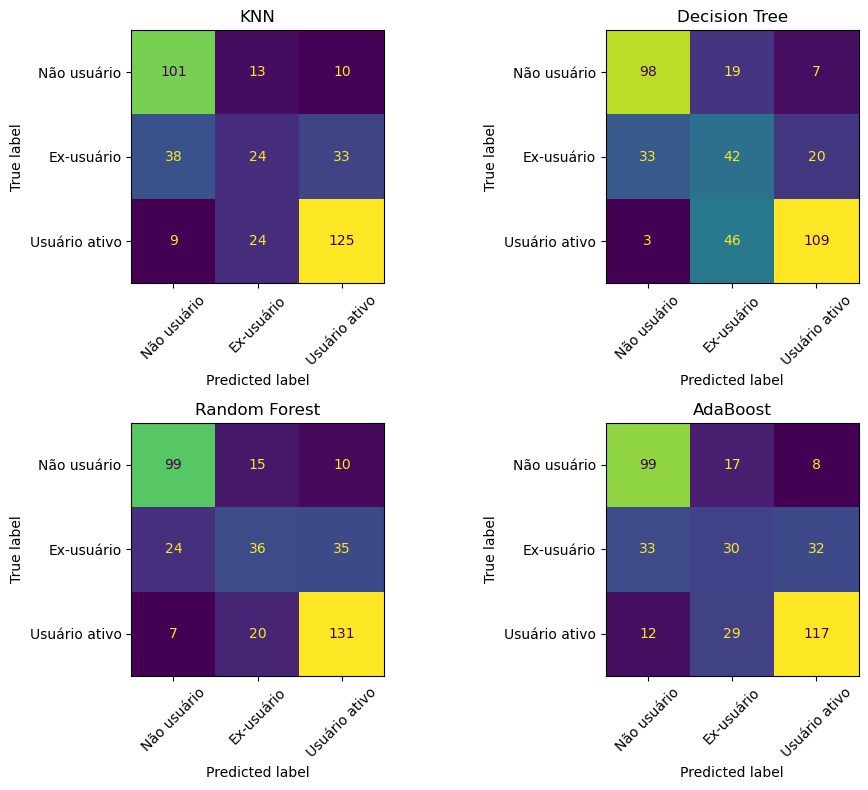

In [108]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(10, 8))

for ax, (name, model) in zip(axes.flatten(), models.items()):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=['Não usuário', 'Ex-usuário', 'Usuário ativo']
    )

    disp.plot(
        ax=ax,
        xticks_rotation=45,
        colorbar=False
    )

    ax.set_title(name)

plt.tight_layout()
plt.show()

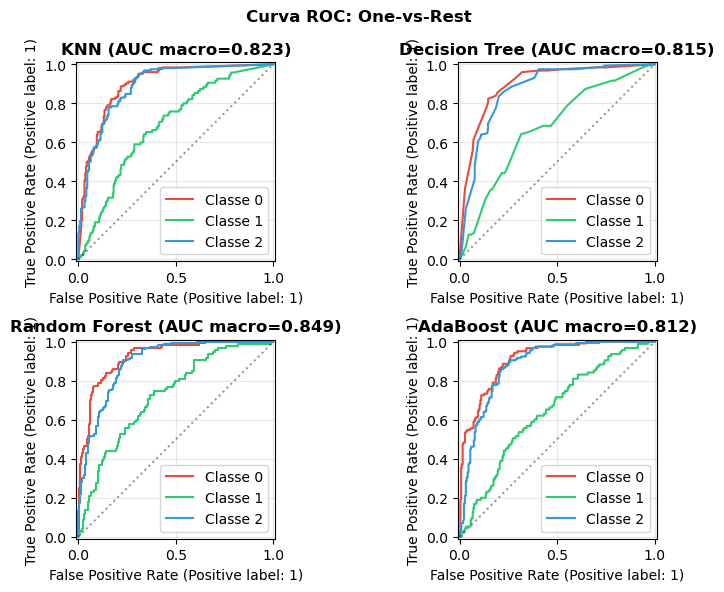

In [109]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import RocCurveDisplay, roc_auc_score

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])

fig, axes = plt.subplots(2, 2, figsize=(8, 6))

for ax, (name, model) in zip(axes.flatten(), models.items()):
    y_score = model.predict_proba(X_test)
    
    for i, cor in zip(range(3), ['#e74c3c', '#2ecc71', '#3498db']):
        RocCurveDisplay.from_predictions(
            y_test_bin[:, i], y_score[:, i],
            ax=ax, 
            curve_kwargs={'color': cor, 'label': f'Classe {i}'}
        )
    
    auc_macro = roc_auc_score(y_test, y_score, multi_class='ovr', average='macro')
    ax.plot([0,1],[0,1], 'k:', alpha=0.4)
    ax.set_title(f'{name} (AUC macro={auc_macro:.3f})', fontweight='bold')
    ax.grid(alpha=0.3)

plt.suptitle('Curva ROC: One-vs-Rest', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Análise dos resultados

Usando o IQR, foi possível visualizar que a porcentagem de outliers variou entre 0 e 1,3%, o que é baixo. E ao remover, não houve melhoria alguma nos modelos. As classes 0 e 2 possuem mais registros. No treinamento foi utilizado GridSearch para procurar os melhores hiperparâmetros para os quatro algoritmos.


Sobre os resultados, o Random Forest foi o melhor modelo, seguido do KNN. Um ponto interessante é que, apesar de ser um modelo mais simples, a Decision Tree ficou muito próxima do KNN. O Adaboost teve a pior acurácia de teste (65%), mas também foi o segundo melhor F1 na validação cruzada. 
As classes 0 e 2 foram 'razoavelmente' bem classificadas por todos os modelos (F1 acima de 0,70), a classe 1 ficou entre 0,31 e 0,43. Ao adicionar as outras drogas nas features, o desempenho melhorou bastante. Isso pode indicar que indivíduos que usam Cannabis, usam outras substâncias também.

Como as classes estão desbalanceadas, o menor desempenho da classe 1 pode estar relacionado com sua baixa representatividade no dataset (classe com menor número de registros). Um ponto de melhoria é aplicar técnicas de balanceamento de classes e avaliar o impacto.